In [16]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
# img = plt.imread("barbara_gray.bmp")
img_pil = Image.open("barbara_gray.bmp")
print(img_pil.size, img_pil.format, img_pil.mode)
img = np.array(img_pil)
print(img[0:4,0:4])
# Image._show(img)

height, width = img.shape[0], img.shape[1]
# plt.imshow(img, cmap='gray')
# print(img.dtype)
P = 10
u1 = 4 
v1 = 5 
u2 = 5 
v2 = 4 # coefficients for embedding (4,5), (5,4)

(512, 512) BMP L
[[220 229 230 227]
 [206 228 229 225]
 [212 227 226 221]
 [221 229 225 220]]


In [12]:
def dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

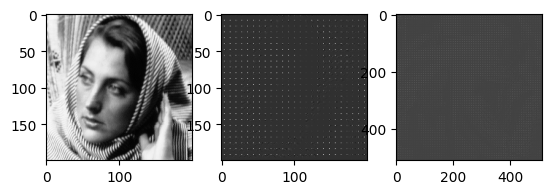

In [17]:
dct_image = np.zeros((height, width))
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = img[i:i+8, j:j+8]
        dct_image[i:i+8, j:j+8] = dct8x8(block)

plt.subplot(1, 3, 1)
plt.imshow(img[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(dct_image[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(dct_image, cmap="gray")

## Embedding message

In [18]:
def adjust_coeffs(block, bit):

    k1 = block[u1, v1]
    k2 = block[u2, v2]
    print(k1, k2, end='\n')
    # if bit == 1 |k1| >= |k2| + P
    # if bit == 0 |k2| >= |k1| + P
    if(bit == 1):
        if abs(k1) >= abs(k2) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = P+1
            new_k2 = 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg + P/2
            new_abs_k2 = avg - P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k1) < abs(new_k2) + P:
                new_k1 = (abs(new_k2) + P)*np.sign(new_k1)
    else:
        if abs(k2) >= abs(k1) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = 1
            new_k2 = P + 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg - P/2
            new_abs_k2 = avg + P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k2) < abs(new_k1) + P:
                new_k2 = (abs(new_k1) + P)*np.sign(new_k2)
    # print(new_k1, new_k2)
    block[u1, v1] = new_k1
    block[u2, v2] = new_k2
    # print(block[u1, v1])
    # print(block[u2, v2])
    return block

In [19]:
message = "BSUIR"
binary_message = ''.join(format(ord(char), '08b') for char in message)
message_len = len(binary_message)
print(binary_message)
print(message_len)

binary_message += '00000000'
bit_index = 0
for i in range(0, height, 8):
    for j in range(0, width, 8):
        if bit_index >= len(binary_message):
            break
        block = dct_image[i:i+8,j:j+8]
        current_bit = int(binary_message[bit_index])
        # block = adjust_coeffs(block, current_bit)
        # np.set_printoptions(precision=1)
        print(bit_index)
        # print("1 ", block)
        dct_image[i:i+8, j:j+8] = adjust_coeffs(block, current_bit)
        print(block[u1, v1], block[u2, v2])
        # print("2 ",dct_image[i:i+8, j:j+8])
        bit_index += 1


0100001001010011010101010100100101010010
40
0
2.3592596609857863 1.8542842020890842
-2.8932280684625646 12.893228068462564
1
2.6336195978153123 -5.152402812050646
11.106988795067021 1.106988795067021
2
-2.3618614507369307 3.3123491303612127
2.1628947094509283 12.162894709450928
3
0.7043464702485931 -1.9878517020251965
-3.6539009138631053 -13.653900913863104
4
-1.1599388240922694 -0.028464729749665157
4.4057982230790325 -14.405798223079032
5
4.775708236145701 -1.7160973713206034
-1.754097196266848 -11.754097196266848
6
5.468513711292177 -2.817628713199136
10.856928787754343 0.8569287877543434
7
-0.6852348945153031 3.0162603755360764
3.14925236497431 13.14925236497431
8
-0.7158916340970507 2.3384005525196994
3.472853906691625 13.472853906691626
9
2.724130540185161 2.1207904499325934
12.577539504941122 -2.5775395049411225
10
-0.9835616848627242 3.59680359088351
2.709817362126883 12.709817362126882
11
-0.14825075706630408 2.5786408624906145
-13.63655419022154 -3.6365541902215406
12
-0.4783

220


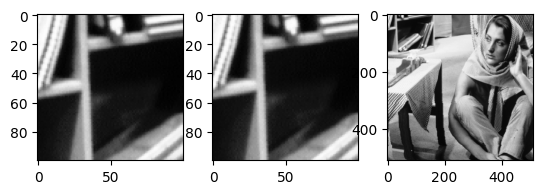

In [20]:
stego_image = np.zeros_like(img)
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = dct_image[i:i+8, j:j+8]
        stego_image[i:i+8, j:j+8] = idct(idct(block.T, norm='ortho').T, norm='ortho')
print(stego_image[0,0])
stego_pil = Image.fromarray(stego_image)
stego_pil.save('stego_image.bmp')
# plt.imsave("stego_image.bmp", stego_image, cmap="gray" )
plt.subplot(1, 3, 1)
plt.imshow(img[0:100, 0:100], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(stego_image[0:100, 0:100], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(stego_image, cmap="gray")

## Extracting message

In [23]:
# stego_image = plt.imread("stego_image.bmp")
stego_pil = Image.open("stego_image.bmp")
stego_image = np.array(stego_pil)
print(stego_image[0,0])
extracted_bits = []
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = stego_image[i:i+8, j:j+8]
        # bit = 1
        block = dct8x8(block)
        k1 = abs(block[u1, v1])
        k2 = abs(block[u2, v2])
        print(k1, k2)
        if k1 >= k2 + P:
            bit = 1
        elif k2 >= k1 + P:
            bit = 0
        else:
            # Если условие не выполняется четко, используем простое сравнение
            bit = 1 if k1 >= k2 else 0
        print(bit)
        extracted_bits.append(bit)
print(extracted_bits)
bytes_array = []
for i in range(0, len(extracted_bits), 8):
    if i+8 > len(extracted_bits):
        break
    byte_bits = extracted_bits[i:i+8]
    byte = 0
    for bit in byte_bits:
        byte = (byte << 1) | bit
    bytes_array.append(byte)
message_dec = ''
for byte in bytes_array:
    if byte == 0:
        break
    message_dec += chr(byte)

print(message_dec)


220
2.408758158655047 13.002353742477
0
11.413864012477852 1.0245216262369836
1
2.193548845212088 12.122497278791727
0
3.769702448787399 13.429890143017953
0
4.919440453187292 14.39769578149015
0
1.4540072628676217 11.52991812711207
0
11.15504550937819 1.0442616600888088
1
3.523415440103178 13.454626209167888
0
3.4641883843341015 13.71146414869172
0
12.590742356702329 2.9250124862180447
1
2.5843597878203837 12.390767955218992
0
13.876752946871413 3.651074636522707
1
4.861409275321587 14.08176828112936
0
3.9858062458367853 14.057192629813748
0
14.41912443361005 4.405918466592676
1
13.270207255402635 3.810235317273924
1
4.846939887043648 14.364926547054779
0
13.212804413913876 2.9242594804042743
1
3.2666560225843684 12.885094550115252
0
11.680760809288579 1.5134185935661282
1
3.5735495303085227 13.758961267352872
0
13.572410632527301 3.4460229505128366
1
4.7487584239375575 14.007646501444587
0
14.914245558290464 5.469486091150157
1
3.9292923448293937 14.111598606648405
0
13.1481460038264